# 📈 AI Stock Price Prediction — Model Comparison

This notebook fetches **3 months of real stock data** from Yahoo Finance and trains three different ML models:

| Model | Type |
|---|---|
| **Linear Regression** | Classical ML |
| **Random Forest** | Ensemble ML |
| **LSTM** | Deep Learning |

Finally, all models are **compared** using MAE, RMSE, and R² metrics.


## 📦 1. Install Dependencies

In [1]:
# Run this cell once to install required packages
import subprocess, sys
pkgs = ['yfinance', 'pandas', 'numpy', 'scikit-learn', 'tensorflow', 'matplotlib', 'seaborn', 'ta']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✅ All packages installed!')

✅ All packages installed!


## 📚 2. Import Libraries

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print(f'✅ Libraries loaded | TF version: {tf.__version__}')

✅ Libraries loaded | TF version: 2.20.0


## 📥 3. Fetch Data from Yahoo Finance
Change `STOCK_SYMBOL` to any NSE stock (e.g. `TCS.NS`, `INFY.NS`, `HDFCBANK.NS`)

In [3]:
# ─── CONFIG ────────────────────────────────────────────────────────────────
STOCK_SYMBOL = 'RELIANCE.NS'   # Change this to any NSE ticker
PERIOD       = '3mo'           # 3 months of data
LOOK_BACK    = 10              # Days used as features for LSTM / RF / LR
TEST_SIZE    = 0.2             # 20% held out for testing
LSTM_EPOCHS  = 50
# ───────────────────────────────────────────────────────────────────────────

print(f'📡 Fetching {PERIOD} data for  {STOCK_SYMBOL} ...')
df_raw = yf.download(STOCK_SYMBOL, period=PERIOD, progress=False, auto_adjust=True)

# Flatten MultiIndex columns if present
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

df_raw.index = pd.to_datetime(df_raw.index)
print(f'✅ Fetched {len(df_raw)} rows   |  {df_raw.index[0].date()} → {df_raw.index[-1].date()}')
df_raw.tail()

📡 Fetching 3mo data for  RELIANCE.NS ...
✅ Fetched 65 rows   |  2025-11-20 → 2026-02-20


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-02-16,1437.099976,1439.599976,1409.300049,1420.099976,5896514
2026-02-17,1423.000000,1431.800049,1418.599976,1431.099976,10731630
2026-02-18,1441.300049,1442.099976,1419.199951,1427.000000,5521096
2026-02-19,1409.500000,1443.000000,1400.000000,1443.000000,11884664
2026-02-20,1419.400024,1427.400024,1406.099976,1409.500000,8177670


## 📊 4. Exploratory Data Analysis

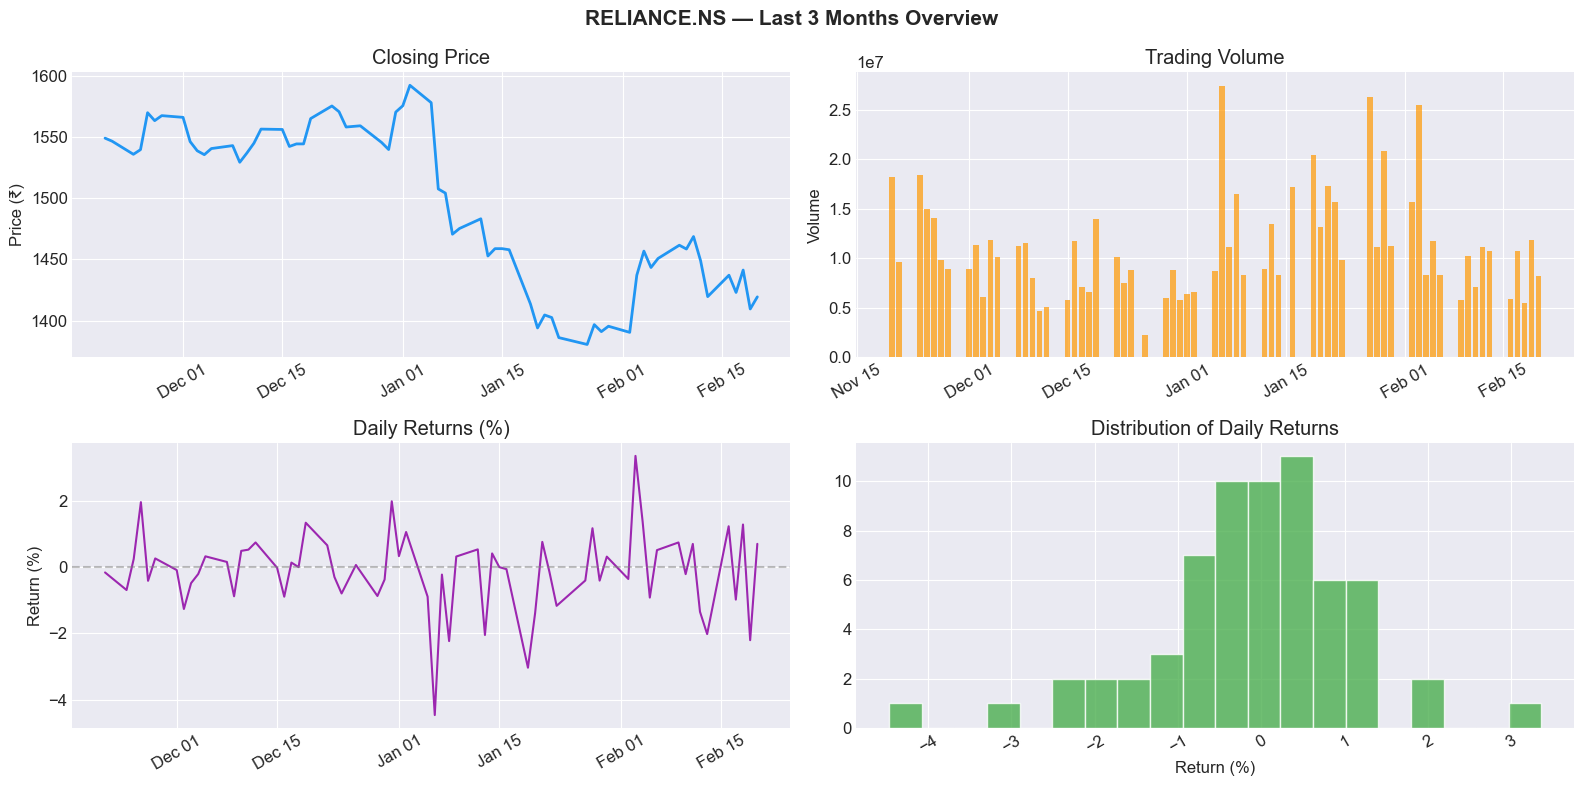


📋 Summary Statistics:


Price,Open,High,Low,Close,Volume
count,65.00,65.00,65.00,65.00,65.00
mean,1496.44,1507.74,1483.14,1494.27,10976829.26
std,65.40,64.01,67.29,65.03,5372558.06
min,1340.00,1391.60,1335.50,1380.50,0.00
25%,1444.00,1452.80,1430.20,1441.30,7506564.00
50%,1530.00,1542.50,1498.00,1507.60,10183266.00
75%,1550.00,1559.80,1540.50,1546.60,13189498.00
max,1593.00,1611.80,1578.20,1592.30,27417125.00


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle(f'{STOCK_SYMBOL} — Last 3 Months Overview', fontsize=15, fontweight='bold')

# Close price
axes[0, 0].plot(df_raw.index, df_raw['Close'], color='#2196F3', linewidth=2)
axes[0, 0].set_title('Closing Price')
axes[0, 0].set_ylabel('Price (₹)')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Volume
axes[0, 1].bar(df_raw.index, df_raw['Volume'], color='#FF9800', alpha=0.7)
axes[0, 1].set_title('Trading Volume')
axes[0, 1].set_ylabel('Volume')
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Daily returns
daily_returns = df_raw['Close'].pct_change().dropna() * 100
axes[1, 0].plot(daily_returns.index, daily_returns, color='#9C27B0', linewidth=1.5)
axes[1, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Daily Returns (%)')
axes[1, 0].set_ylabel('Return (%)')
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Distribution of returns
axes[1, 1].hist(daily_returns, bins=20, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Distribution of Daily Returns')
axes[1, 1].set_xlabel('Return (%)')

for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('\n📋 Summary Statistics:')
display(df_raw[['Open','High','Low','Close','Volume']].describe().round(2))

## 🔧 5. Feature Engineering
Create lag features and technical indicators used by all three models.

In [5]:
df = df_raw[['Close']].copy()

# ── Lag features (last N closing prices as inputs)
for lag in range(1, LOOK_BACK + 1):
    df[f'Lag_{lag}'] = df['Close'].shift(lag)

# ── Rolling statistics
df['MA_5']   = df['Close'].rolling(5).mean()
df['MA_10']  = df['Close'].rolling(10).mean()
df['STD_5']  = df['Close'].rolling(5).std()

# ── Momentum: % change over past 5 days
df['Momentum'] = df['Close'].pct_change(5)

# ── Target: next day's close
df['Target'] = df['Close'].shift(-1)

df.dropna(inplace=True)
print(f'✅ Feature matrix shape: {df.shape}')
print(f'   Features used: {[c for c in df.columns if c != "Target"]}')
df.head()

✅ Feature matrix shape: (54, 16)
   Features used: ['Close', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5', 'Lag_6', 'Lag_7', 'Lag_8', 'Lag_9', 'Lag_10', 'MA_5', 'MA_10', 'STD_5', 'Momentum']


Price,Close,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,Lag_9,Lag_10,MA_5,MA_10,STD_5,Momentum,Target
Date,,,,,,,,,,,,,,,,
2025-12-04,1535.599976,1538.800049,1546.300049,1566.099976,1567.500000,1563.400024,1569.900024,1539.699951,1535.900024,1546.599976,1549.099976,1550.860010,1550.980005,15.068596,-0.017782,1540.599976
2025-12-05,1540.599976,1535.599976,1538.800049,1546.300049,1566.099976,1567.500000,1563.400024,1569.900024,1539.699951,1535.900024,1546.599976,1545.480005,1550.380005,12.164571,-0.017161,1543.000000
2025-12-08,1543.000000,1540.599976,1535.599976,1538.800049,1546.300049,1566.099976,1567.500000,1563.400024,1569.900024,1539.699951,1535.900024,1540.860010,1551.090002,4.066712,-0.014750,1529.400024
2025-12-09,1529.400024,1543.000000,1540.599976,1535.599976,1538.800049,1546.300049,1566.099976,1567.500000,1563.400024,1569.900024,1539.699951,1537.480005,1550.060010,5.262311,-0.010929,1536.900024
2025-12-10,1536.900024,1529.400024,1543.000000,1540.599976,1535.599976,1538.800049,1546.300049,1566.099976,1567.500000,1563.400024,1569.900024,1537.100000,1546.760010,5.211514,-0.001235,1545.000000


## ✂️ 6. Train / Test Split

In [6]:
feature_cols = [c for c in df.columns if c not in ['Target']]

X = df[feature_cols].values
y = df['Target'].values
dates = df.index

split_idx = int(len(X) * (1 - TEST_SIZE))

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test       = dates[split_idx:]

print(f'Train samples : {len(X_train)}')
print(f'Test  samples : {len(X_test)}')

# ── Scale features (required for LSTM, neutral for others)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

Train samples : 43
Test  samples : 11


---
## 🔵 7. Model 1 — Linear Regression

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)

lr_pred = lr_model.predict(X_test_sc)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  🔵 LINEAR REGRESSION RESULTS')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  MAE  : ₹{lr_mae:.2f}')
print(f'  RMSE : ₹{lr_rmse:.2f}')
print(f'  R²   : {lr_r2:.4f}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔵 LINEAR REGRESSION RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : ₹26.05
  RMSE : ₹32.35
  R²   : -1.9524


---
## 🟠 8. Model 2 — Random Forest Regressor

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=3,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sc, y_train)

rf_pred = rf_model.predict(X_test_sc)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  🟠 RANDOM FOREST RESULTS')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  MAE  : ₹{rf_mae:.2f}')
print(f'  RMSE : ₹{rf_rmse:.2f}')
print(f'  R²   : {rf_r2:.4f}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🟠 RANDOM FOREST RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : ₹22.26
  RMSE : ₹23.81
  R²   : -0.6003


### 🌲 Feature Importance (Random Forest)

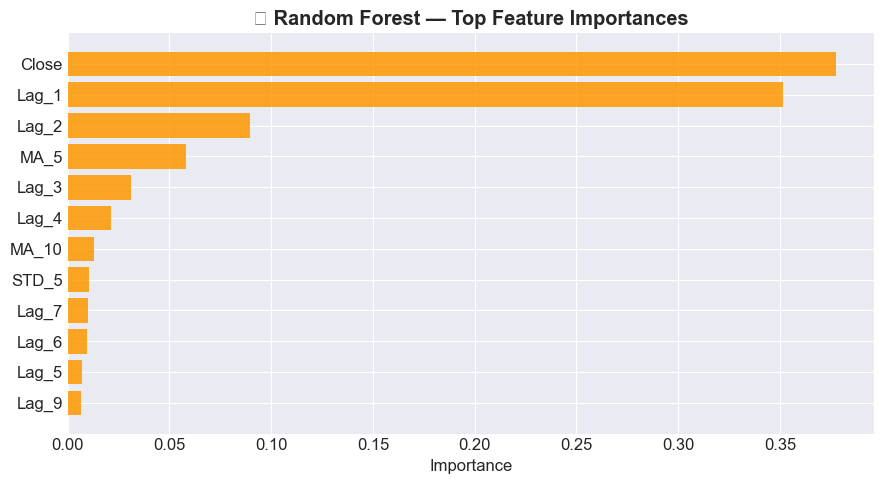

In [9]:
importance = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importance})
feat_df = feat_df.sort_values('Importance', ascending=True).tail(12)

plt.figure(figsize=(9, 5))
bars = plt.barh(feat_df['Feature'], feat_df['Importance'], color='#FF9800', alpha=0.85)
plt.title('🌲 Random Forest — Top Feature Importances', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---
## 🟣 9. Model 3 — LSTM (Long Short-Term Memory)

In [10]:
# ── Reshape for LSTM: (samples, timesteps, features)
X_train_lstm = X_train_sc.reshape((X_train_sc.shape[0], 1, X_train_sc.shape[1]))
X_test_lstm  = X_test_sc.reshape((X_test_sc.shape[0],  1, X_test_sc.shape[1]))

# ── Build LSTM model
tf.random.set_seed(42)
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_train_sc.shape[1])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,441 (130.63 KB)

 Trainable params: 33,441 (130.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 267ms/step - loss: 0.4480 - mae: 0.6010 - val_loss: 0.0354 - val_mae: 0.1382
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.3622 - mae: 0.5341 - val_loss: 0.0280 - val_mae: 0.1145
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2804 - mae: 0.4624 - val_loss: 0.0222 - val_mae: 0.1164
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2005 - mae: 0.3887 - val_loss: 0.0186 - val_mae: 0.1239
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1300 - mae: 0.3095 - val_loss: 0.0183 - val_mae: 0.1324
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0739 - mae: 0.2324 - val_loss: 0.0220 - val_mae: 0.1412
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0479 - mae: 0.1815 - val_loss: 0.0276 - val_mae: 0.1481
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0594 - mae: 0.1981 - val_loss: 0.0303 - val_mae: 0.1503
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0573 - mae: 0.1918 -

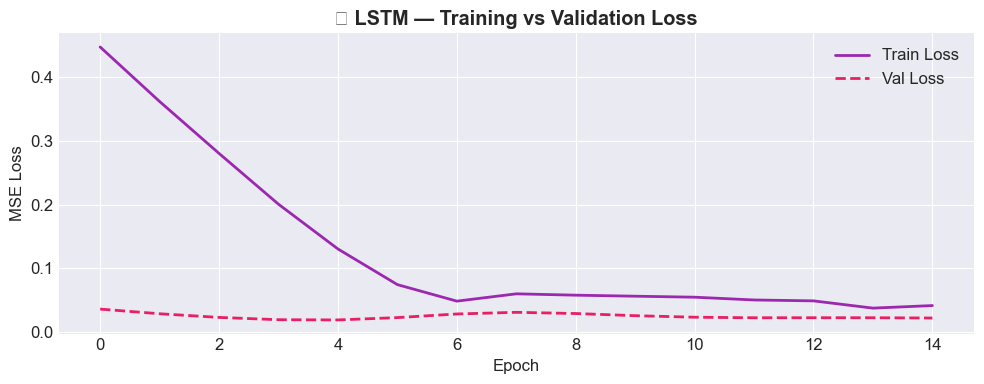

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train_sc,
    epochs=LSTM_EPOCHS,
    batch_size=8,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='#9C27B0', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss',   color='#E91E63', linewidth=2, linestyle='--')
plt.title('🟣 LSTM — Training vs Validation Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
lstm_pred_sc = lstm_model.predict(X_test_lstm).ravel()

# Inverse transform back to actual prices
lstm_pred = scaler_y.inverse_transform(lstm_pred_sc.reshape(-1, 1)).ravel()

lstm_mae  = mean_absolute_error(y_test, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
lstm_r2   = r2_score(y_test, lstm_pred)

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  🟣 LSTM RESULTS')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  MAE  : ₹{lstm_mae:.2f}')
print(f'  RMSE : ₹{lstm_rmse:.2f}')
print(f'  R²   : {lstm_r2:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🟣 LSTM RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : ₹21.56
  RMSE : ₹25.23
  R²   : -0.7967


---
## 📊 10. Model Comparison — Metrics Table

In [13]:
results = pd.DataFrame({
    'Model':  ['Linear Regression', 'Random Forest', 'LSTM'],
    'MAE (₹)':  [lr_mae,  rf_mae,  lstm_mae],
    'RMSE (₹)': [lr_rmse, rf_rmse, lstm_rmse],
    'R² Score':  [lr_r2,   rf_r2,   lstm_r2]
})

results = results.sort_values('RMSE (₹)').reset_index(drop=True)
results.index += 1  # Rank starting from 1

# Highlight best values
def highlight_best(col):
    if col.name == 'R² Score':
        is_best = col == col.max()
    else:
        is_best = col == col.min()
    return ['background-color: #c8f7c5; font-weight: bold' if v else '' for v in is_best]

styled = (
    results.style
    .apply(highlight_best, subset=['MAE (₹)', 'RMSE (₹)', 'R² Score'])
    .format({'MAE (₹)': '₹{:.2f}', 'RMSE (₹)': '₹{:.2f}', 'R² Score': '{:.4f}'})
    .set_caption('🏆 Model Comparison — Green = Best')
)
display(styled)

,Model,MAE (₹),RMSE (₹),R² Score
1,Random Forest,₹22.26,₹23.81,-0.6003
2,LSTM,₹21.56,₹25.23,-0.7967
3,Linear Regression,₹26.05,₹32.35,-1.9524


## 📊 11. Metric Bar Charts — Side by Side

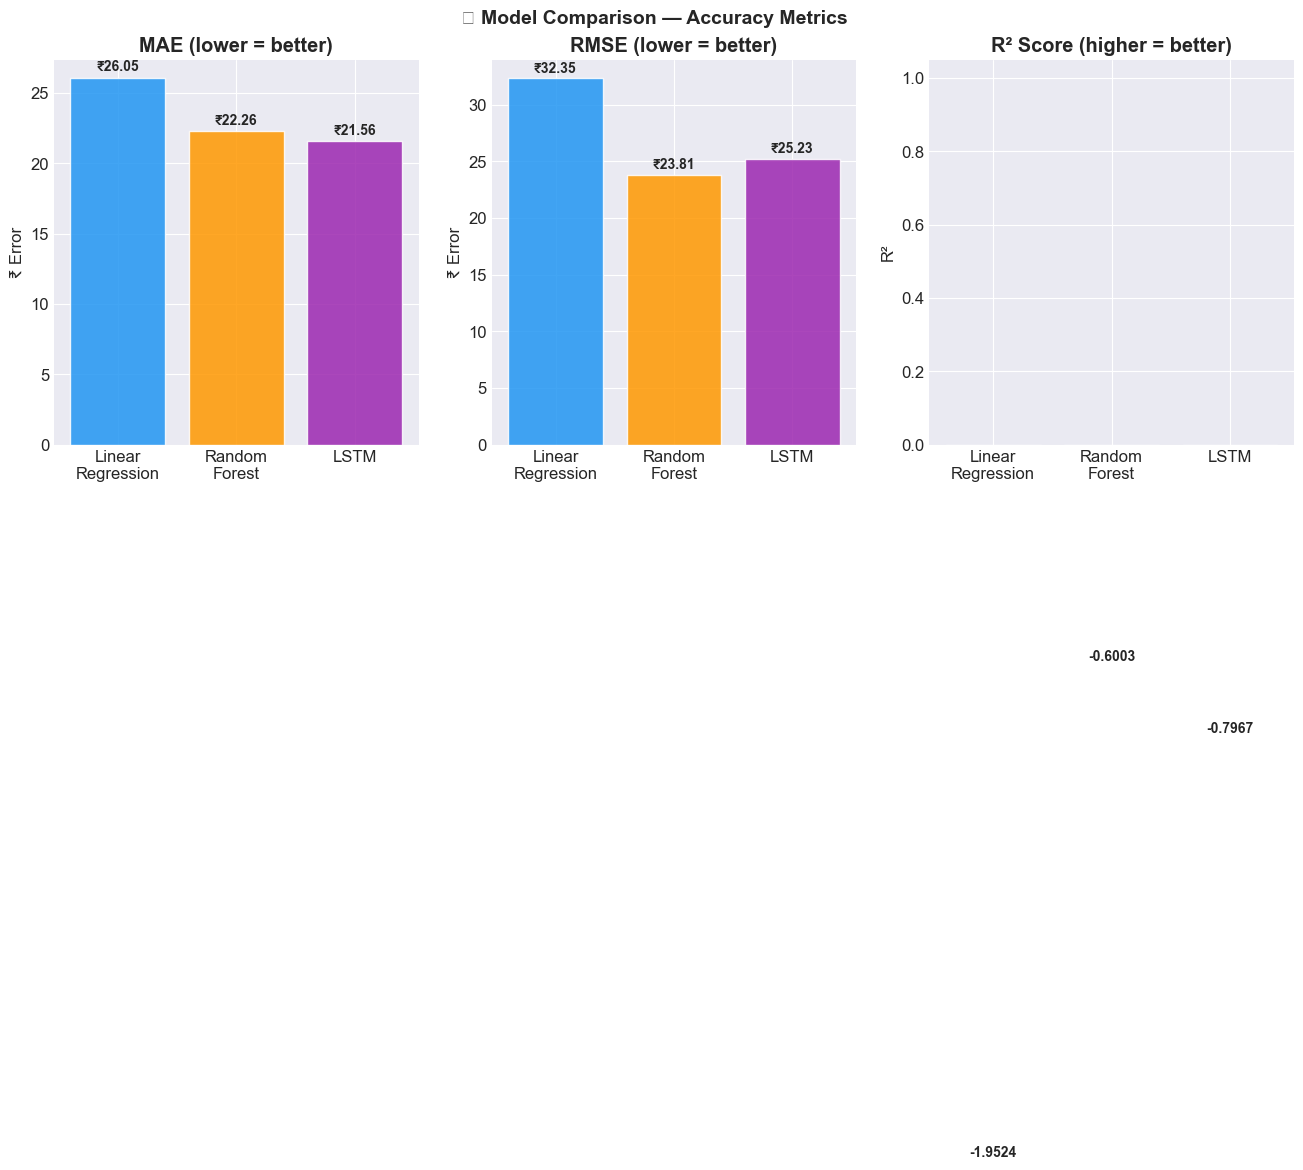

In [14]:
models_list = ['Linear\nRegression', 'Random\nForest', 'LSTM']
colors      = ['#2196F3', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('📊 Model Comparison — Accuracy Metrics', fontsize=14, fontweight='bold')

# MAE
bars = axes[0].bar(models_list, [lr_mae, rf_mae, lstm_mae], color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('MAE (lower = better)', fontweight='bold')
axes[0].set_ylabel('₹ Error')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'₹{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

# RMSE
bars = axes[1].bar(models_list, [lr_rmse, rf_rmse, lstm_rmse], color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('RMSE (lower = better)', fontweight='bold')
axes[1].set_ylabel('₹ Error')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'₹{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

# R²
bars = axes[2].bar(models_list, [lr_r2, rf_r2, lstm_r2], color=colors, alpha=0.85, edgecolor='white')
axes[2].set_title('R² Score (higher = better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1.05)
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 📈 12. Predicted vs Actual Prices — All Models

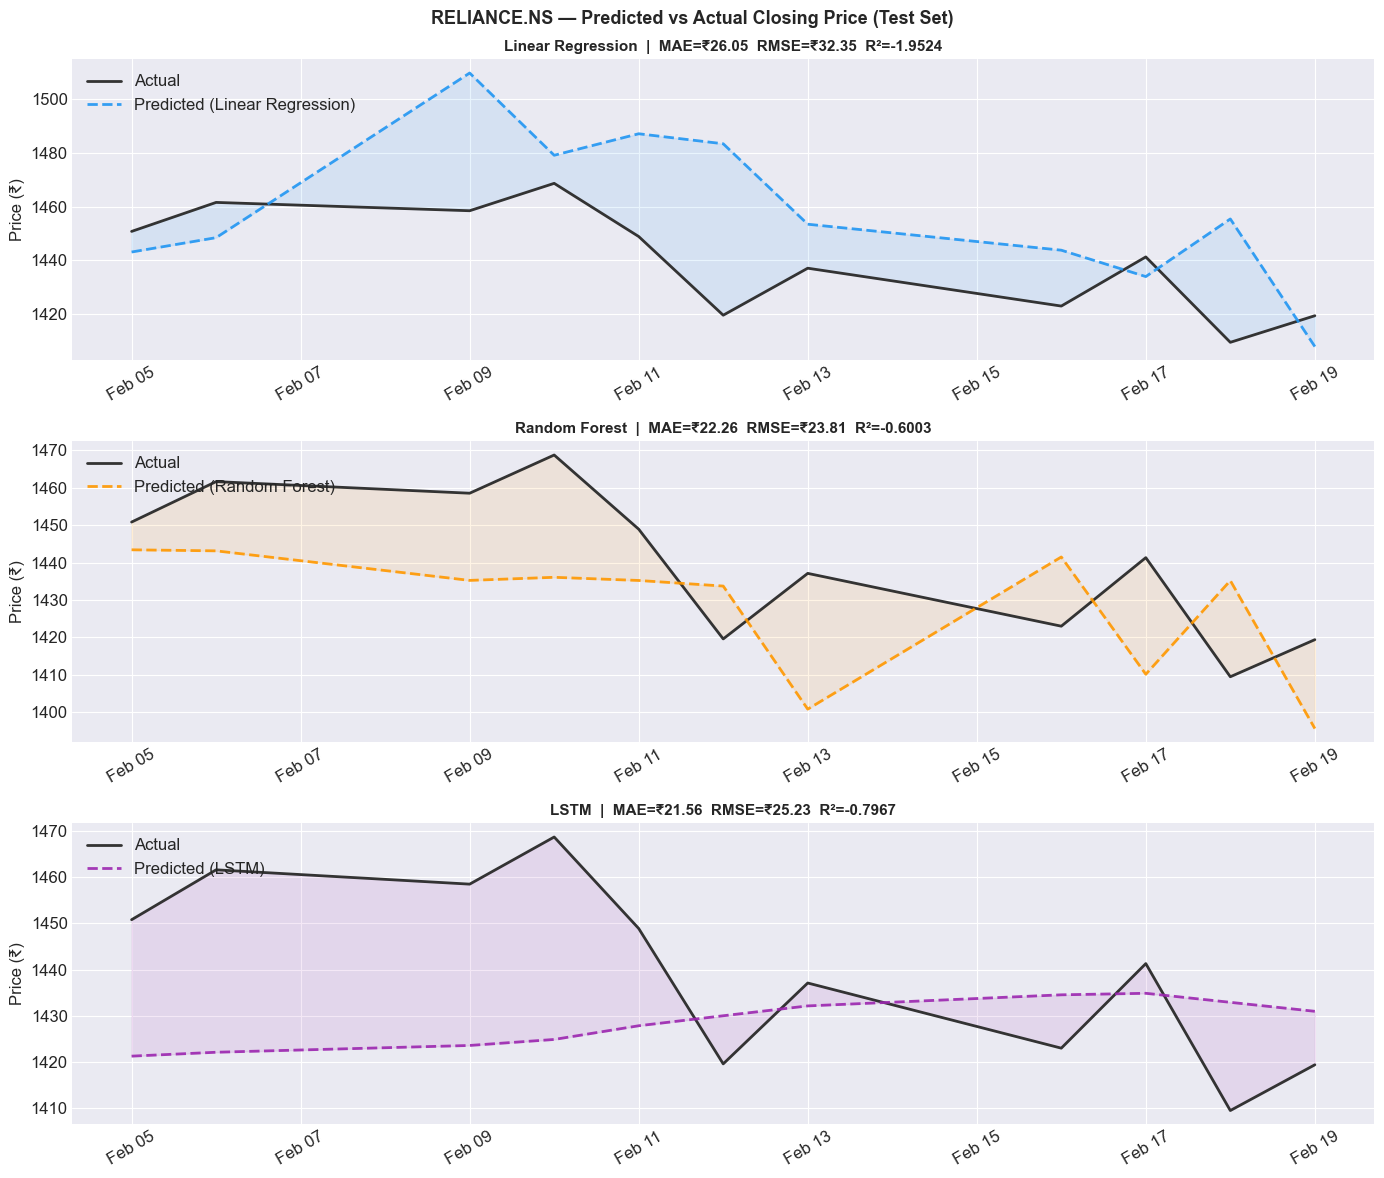

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(f'{STOCK_SYMBOL} — Predicted vs Actual Closing Price (Test Set)', 
             fontsize=13, fontweight='bold')

plot_data = [
    ('Linear Regression', lr_pred,   '#2196F3', lr_mae,  lr_rmse,  lr_r2),
    ('Random Forest',     rf_pred,   '#FF9800', rf_mae,  rf_rmse,  rf_r2),
    ('LSTM',              lstm_pred, '#9C27B0', lstm_mae,lstm_rmse,lstm_r2),
]

for ax, (name, pred, color, mae, rmse, r2) in zip(axes, plot_data):
    ax.plot(dates_test, y_test, label='Actual',    color='#333333', linewidth=2, zorder=2)
    ax.plot(dates_test, pred,   label=f'Predicted ({name})', color=color,
            linewidth=2, linestyle='--', alpha=0.9, zorder=3)
    ax.fill_between(dates_test, y_test, pred, alpha=0.1, color=color)
    ax.set_title(f'{name}  |  MAE=₹{mae:.2f}  RMSE=₹{rmse:.2f}  R²={r2:.4f}', 
                 fontweight='bold', fontsize=11)
    ax.set_ylabel('Price (₹)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 🏆 13. Final Verdict

In [ ]:
# Determine best model by RMSE (lower = better)
model_scores = {
    'Linear Regression': lr_rmse,
    'Random Forest':     rf_rmse,
    'LSTM':              lstm_rmse
}
best_model = min(model_scores, key=model_scores.get)

emoji_map = {'Linear Regression': '🔵', 'Random Forest': '🟠', 'LSTM': '🟣'}

print('=' * 50)
print('  🏆  FINAL MODEL COMPARISON SUMMARY')
print('=' * 50)
for model, rmse in sorted(model_scores.items(), key=lambda x: x[1]):
    tag = '  ← 🏅 BEST' if model == best_model else ''
    print(f'  {emoji_map[model]}  {model:<22} RMSE: ₹{rmse:.2f}{tag}')
print('=' * 50)
print(f'\n  ✅ Best performing model: {emoji_map[best_model]} {best_model}')
print(f'  Lowest RMSE: ₹{model_scores[best_model]:.2f}')
print()
print('  📌 Metric Guide:')
print('     MAE   = Average absolute error in ₹')
print('     RMSE  = Penalises large errors more (lower = better)')
print('     R²    = Variance explained by model (1.0 = perfect)')

  🏆  FINAL MODEL COMPARISON SUMMARY
  🟠  Random Forest          RMSE: ₹23.81  ← 🏅 BEST
  🟣  LSTM                   RMSE: ₹25.23
  🔵  Linear Regression      RMSE: ₹32.35

  ✅ Best performing model: 🟠 Random Forest
  Lowest RMSE: ₹23.81

  📌 Metric Guide:
     MAE   = Average absolute error in ₹
     RMSE  = Penalises large errors more (lower = better)
     R²    = Variance explained by model (1.0 = perfect)


: 